# Exp03 K-Action Descriptive Overview

This notebook summarizes the full `mu` scan for the endogenous-K experiment. It tracks three questions: how evaluation `delta` varies across `mu`, how often runs converge and how long convergence takes, and how post-convergence `K`, rule action, and `K`-action pair usage differ under both decision-share and time-share views.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("../..").resolve()
RESULTS_DIR = PROJECT_ROOT / "data" / "results_exp03"
sys.path.append(str(PROJECT_ROOT))

from src_ext_K_action.strategies import ID_TO_NAME

styles = {
    "3 Rules": "solid",
    "4 Rules": "dashed",
}
markers = {"3 Rules": "o", "4 Rules": "s"}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cap_width = (MU_VALUES[1] - MU_VALUES[0]) * 0.08
shift_amount = cap_width * 0.35

from matplotlib.lines import Line2D

for ruleset, style in styles.items():
    delta_part = delta_summary[delta_summary[\"ruleset\"] == ruleset].sort_values(\"mu\")
    mus = delta_part[\"mu\"].to_numpy()
    means = delta_part[\"delta_mean\"].to_numpy()
    sds = delta_part[\"delta_sd\"].to_numpy()
    marker = markers[ruleset]
    for mu, m, sd in zip(mus, means, sds):
        mu_plot = mu + shift_amount if ruleset == "4 Rules" else mu
        axes[0].plot(mu_plot, m, marker=marker, color="k", linestyle="None", markersize=4)
        axes[0].vlines(mu_plot, m - sd, m + sd, color="k", linestyle=style, linewidth=1)
        axes[0].hlines([m - sd, m + sd], mu_plot - cap_width, mu_plot + cap_width, color="k", linestyle=style, linewidth=1)

    conv_part = convergence_summary[convergence_summary[\"ruleset\"] == ruleset].sort_values(\"mu\")
    mus = conv_part[\"mu\"].to_numpy()
    means = conv_part[\"episode_mean\"].to_numpy()
    sds = conv_part[\"episode_sd\"].to_numpy()
    for mu, m, sd in zip(mus, means, sds):
        mu_plot = mu + shift_amount if ruleset == "4 Rules" else mu
        axes[1].plot(mu_plot, m, marker=marker, color="k", linestyle="None", markersize=4)
        axes[1].vlines(mu_plot, m - sd, m + sd, color="k", linestyle=style, linewidth=1)
        axes[1].hlines([m - sd, m + sd], mu_plot - cap_width, mu_plot + cap_width, color="k", linestyle=style, linewidth=1)

# Legend: show solid vs dashed with marker
handles = [Line2D([0], [0], color="k", linestyle=styles[r], marker=markers[r], markersize=6, label=r) for r in styles]
axes[0].legend(handles=handles, frameon=False)
axes[1].legend(handles=handles, frameon=False)

axes[0].set_title(r\"Evaluation $\\Delta$ by $\\mu$\")
axes[0].set_xlabel(r\"$\\mu$\")
axes[0].set_ylabel(r\"Mean $\\Delta$\")

axes[1].set_title(\"Training Episodes to Convergence\")
axes[1].set_xlabel(r\"$\\mu$\")
axes[1].set_ylabel(\"Mean Episode\")
axes[1].ticklabel_format(style=\"plain\", axis=\"y\")

fig.tight_layout()
plt.show()
            df = pd.read_parquet(parquet_file, columns=base_cols + seller_cols)
            run_id = parquet_file.stem.split("_")[-1]
            converged = bool(df["converged"].iloc[0])
            run_rows.append({
                "run_id": run_id,
                "ruleset": ruleset,
                "mu": mu,
                "delta_mean": float(df["delta"].mean()),
                "episode": int(df["episode"].iloc[0]),
                "converged": converged,
            })

            if not converged:
                continue

            time_parts = [] # includes all steps, regardless of decision
            decision_parts = [] # includes only steps where step_in_base_K == 0 and decision is True. These are the steps when seller is making a decision
            # if a seller chooses K=30 at a decision step, k_seller stays 30 periods for the next 30 rows until the next decision; time_parts therefore has equal rows per seller, while decision_parts counts decision events only and seller with diff K choices has diff decision_parts counts.
            # Define decision_{seller}: =1 if the seller is making an action at the step, =0 if not.
            for seller in SELLERS:
                time_parts.append(
                    df[[f"a_{seller}", f"k_{seller}"]].rename(
                        columns={f"a_{seller}": "action_id", f"k_{seller}": "K"}
                    )
                )
                decision_mask = df[f"decision_{seller}"] & (df["step_in_base_K"] == 0) 
                decision_parts.append(
                    df.loc[decision_mask, [f"a_{seller}", f"k_{seller}"]].rename(
                        columns={f"a_{seller}": "action_id", f"k_{seller}": "K"}
                    )
                )

            for share_basis, part in {
                "time share": pd.concat(time_parts, ignore_index=True),
                "decision share": pd.concat(decision_parts, ignore_index=True),
            }.items():
                counts = part.groupby(["action_id", "K"]).size().reset_index(name="count")
                counts["share_basis"] = share_basis
                counts["ruleset"] = ruleset
                counts["mu"] = mu
                counts['run_id'] = run_id
                count_frames.append(counts)

run_metrics = pd.DataFrame(run_rows)
pair_counts = pd.concat(count_frames, ignore_index=True)

In [10]:
run_metrics.head(), run_metrics.shape # 10 mu values x 2 rulesets x 30 runs = 600 rows

(  run_id  ruleset    mu  delta_mean  episode  converged
 0      0  3 Rules  0.04    1.000000   652313       True
 1      1  3 Rules  0.04    0.571977   382350       True
 2     10  3 Rules  0.04    1.000000   523583       True
 3     11  3 Rules  0.04    1.000000   580533       True
 4     12  3 Rules  0.04    1.000000   671831       True,
 (600, 6))

In [16]:
pair_counts.head(50), pair_counts.shape # 2 share bases x 10 mu values x 3 K values x (3 action_ids + 4 action_ids) x 30 runs = 3600 rows. But many action_id + K combinations will have 0 count, so actual rows will be less. 

(    action_id   K  count     share_basis  ruleset    mu run_id
 0           1  10   2000      time share  3 Rules  0.04      0
 1           1  30   2000      time share  3 Rules  0.04      0
 2           1  60   2000      time share  3 Rules  0.04      0
 3           1  10    200  decision share  3 Rules  0.04      0
 4           1  30     67  decision share  3 Rules  0.04      0
 5           1  60     34  decision share  3 Rules  0.04      0
 6           0  10    870      time share  3 Rules  0.04      1
 7           1  60   1710      time share  3 Rules  0.04      1
 8           2  30     30      time share  3 Rules  0.04      1
 9           2  60   3390      time share  3 Rules  0.04      1
 10          0  10     87  decision share  3 Rules  0.04      1
 11          1  60     29  decision share  3 Rules  0.04      1
 12          2  30      1  decision share  3 Rules  0.04      1
 13          2  60     57  decision share  3 Rules  0.04      1
 14          1  10   2000      time shar

In [18]:
delta_summary = (
    run_metrics.groupby(["ruleset", "mu"], as_index=False)
    .agg(
        delta_mean=("delta_mean", "mean"),
        delta_sd=("delta_mean", "std"),
        n_runs=("delta_mean", "size"),
    )
)

convergence_summary = (
    run_metrics.groupby(["ruleset", "mu"], as_index=False)
    .agg(
        converged_rate=("converged", "mean"),
        episode_mean=("episode", "mean"),
        episode_sd=("episode", "std"),
        episode_min=("episode", "min"),
        episode_max=("episode", "max"),
    )
)

pair_share_summary = (
    pair_counts.groupby(["share_basis", "ruleset", "mu", "action_id", "K"], as_index=False)["count"]
    .sum()
)
pair_share_summary["share"] = (
    pair_share_summary["count"]
    / pair_share_summary.groupby(["share_basis", "ruleset", "mu"])["count"].transform("sum")
)
pair_share_summary["action"] = pair_share_summary["action_id"].map(ID_TO_NAME)
pair_share_summary["pair"] = pair_share_summary["action"] + " | K=" + pair_share_summary["K"].astype(str)
pair_share_summary = pair_share_summary[["share_basis", "ruleset", "mu", "action", "K", "pair", "share"]]

k_share_summary = (
    pair_share_summary.groupby(["share_basis", "ruleset", "mu", "K"], as_index=False)["share"]
    .sum()
)

action_share_summary = (
    pair_share_summary.groupby(["share_basis", "ruleset", "mu", "action"], as_index=False)["share"]
    .sum()
)

delta_summary.round(4)

,ruleset,mu,delta_mean,delta_sd,n_runs
0,3 Rules,0.04,0.9328,0.1387,30
1,3 Rules,0.07,0.8810,0.1076,30
2,3 Rules,0.10,0.9277,0.0858,30
3,3 Rules,0.13,0.9730,0.0507,30
4,3 Rules,0.16,0.9498,0.0546,30
5,3 Rules,0.19,0.9825,0.0369,30
6,3 Rules,0.22,0.9794,0.0380,30
7,3 Rules,0.25,0.9781,0.0369,30
8,3 Rules,0.28,0.9912,0.0241,30
9,3 Rules,0.31,0.9942,0.0177,30


In [19]:
convergence_summary.round({
    "converged_rate": 3,
    "episode_mean": 1,
    "episode_sd": 1,
})

,ruleset,mu,converged_rate,episode_mean,episode_sd,episode_min,episode_max
0,3 Rules,0.04,1.0,564138.2,87473.2,350595,703613
1,3 Rules,0.07,1.0,522416.5,103329.5,315445,682020
2,3 Rules,0.10,1.0,546149.0,93242.6,347435,697415
3,3 Rules,0.13,1.0,585981.7,84483.0,400960,797261
4,3 Rules,0.16,1.0,589781.8,92055.1,377445,765645
5,3 Rules,0.19,1.0,623211.2,88091.2,398171,734547
6,3 Rules,0.22,1.0,608430.8,69872.8,386594,699535
7,3 Rules,0.25,1.0,611535.5,87183.7,442226,727118
8,3 Rules,0.28,1.0,639772.5,51212.5,526746,764218
9,3 Rules,0.31,1.0,639091.6,57223.2,459842,753375


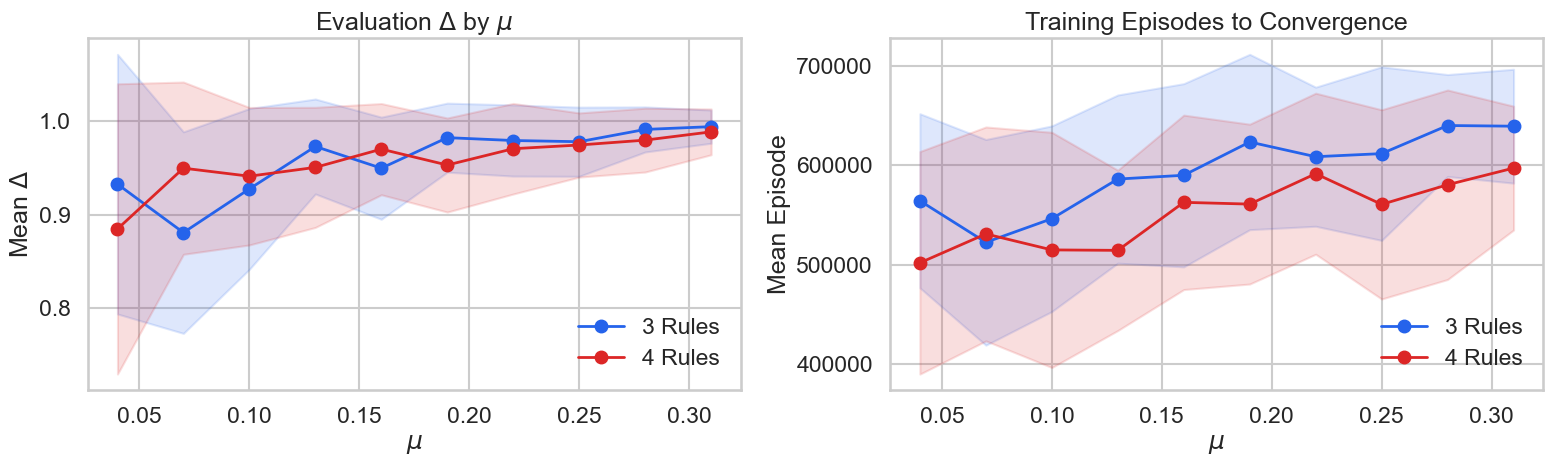

In [22]:
palette = {
    "3 Rules": "#2563eb",
    "4 Rules": "#dc2626",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ruleset, color in palette.items():
    delta_part = delta_summary[delta_summary["ruleset"] == ruleset].sort_values("mu")
    axes[0].plot(delta_part["mu"], delta_part["delta_mean"], marker="o", linewidth=2, label=ruleset, color=color)
    axes[0].fill_between(
        delta_part["mu"],
        delta_part["delta_mean"] - delta_part["delta_sd"],
        delta_part["delta_mean"] + delta_part["delta_sd"],
        color=color,
        alpha=0.15,
    )

    conv_part = convergence_summary[convergence_summary["ruleset"] == ruleset].sort_values("mu")
    axes[1].plot(conv_part["mu"], conv_part["episode_mean"], marker="o", linewidth=2, label=ruleset, color=color)
    axes[1].fill_between(
        conv_part["mu"],
        conv_part["episode_mean"] - conv_part["episode_sd"],
        conv_part["episode_mean"] + conv_part["episode_sd"],
        color=color,
        alpha=0.15,
    )

axes[0].set_title(r"Evaluation $\Delta$ by $\mu$")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"Mean $\Delta$")
axes[0].legend(frameon=False)

axes[1].set_title("Training Episodes to Convergence")
axes[1].set_xlabel(r"$\mu$")
axes[1].set_ylabel("Mean Episode")
axes[1].ticklabel_format(style="plain", axis="y")
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

In [23]:
k_share_pivot = k_share_summary.pivot_table(
    index=["share_basis", "ruleset", "K"],
    columns="mu",
    values="share",
    fill_value=0,
).round(2)

action_share_pivot = action_share_summary.pivot_table(
    index=["share_basis", "ruleset", "action"],
    columns="mu",
    values="share",
    fill_value=0,
).round(2)

top_pair_summary = (
    pair_share_summary.sort_values(["share_basis", "ruleset", "mu", "share"], ascending=[True, True, True, False])
    .groupby(["share_basis", "ruleset", "mu"], as_index=False)
    .head(3)
    .reset_index(drop=True)
)

k_share_pivot

mu                         0.04  0.07  0.10  0.13  0.16  0.19  0.22  0.25  \
share_basis    ruleset K                                                    
decision share 3 Rules 10  0.51  0.42  0.54  0.69  0.64  0.77  0.75  0.87   
                       30  0.29  0.25  0.21  0.16  0.15  0.14  0.13  0.05   
                       60  0.21  0.33  0.25  0.15  0.21  0.09  0.11  0.08   
               4 Rules 10  0.74  0.66  0.65  0.69  0.71  0.70  0.74  0.72   
                       30  0.12  0.19  0.18  0.14  0.14  0.14  0.15  0.15   
                       60  0.14  0.16  0.17  0.17  0.15  0.16  0.11  0.14   
time share     3 Rules 10  0.20  0.14  0.21  0.33  0.28  0.45  0.41  0.58   
                       30  0.33  0.24  0.23  0.24  0.20  0.24  0.22  0.10   
                       60  0.47  0.62  0.56  0.43  0.52  0.31  0.37  0.32   
               4 Rules 10  0.38  0.31  0.30  0.33  0.35  0.34  0.40  0.36   
                       30  0.19  0.26  0.25  0.20  0.21  0.21  0.25  0.22   
                       60  0.43  0.44  0.45  0.47  0.44  0.46  0.35  0.41   

mu                         0.28  0.31  
share_basis    ruleset K               
decision share 3 Rules 10  0.77  0.86  
                       30  0.13  0.10  
                       60  0.10  0.04  
               4 Rules 10  0.78  0.87  
                       30  0.12  0.07  
                       60  0.10  0.06  
time share     3 Rules 10  0.44  0.61  
                       30  0.22  0.22  
                       60  0.33  0.17  
               4 Rules 10  0.45  0.61  
                       30  0.21  0.14  
                       60  0.34  0.26

In [24]:
action_share_pivot

mu                                  0.04  0.07  0.10  0.13  0.16  0.19  0.22  \
share_basis    ruleset action                                                  
decision share 3 Rules Above        0.06  0.19  0.11  0.05  0.11  0.03  0.05   
                       Match        0.88  0.63  0.78  0.91  0.78  0.94  0.91   
                       Undercut     0.07  0.18  0.11  0.04  0.10  0.03  0.04   
               4 Rules Above        0.07  0.05  0.10  0.09  0.06  0.13  0.07   
                       Match        0.84  0.89  0.81  0.84  0.87  0.78  0.89   
                       Under+Reset  0.03  0.03  0.04  0.03  0.05  0.03  0.03   
                       Undercut     0.05  0.02  0.05  0.05  0.02  0.06  0.02   
time share     3 Rules Above        0.12  0.32  0.25  0.14  0.27  0.11  0.13   
                       Match        0.86  0.62  0.71  0.84  0.69  0.88  0.84   
                       Undercut     0.03  0.06  0.04  0.02  0.04  0.02  0.02   
               4 Rules Above        0.21  0.13  0.23  0.21  0.17  0.29  0.19   
                       Match        0.75  0.84  0.72  0.75  0.80  0.67  0.79   
                       Under+Reset  0.02  0.02  0.02  0.01  0.02  0.02  0.01   
                       Undercut     0.03  0.01  0.02  0.02  0.01  0.03  0.01   

mu                                  0.25  0.28  0.31  
share_basis    ruleset action                         
decision share 3 Rules Above        0.04  0.02  0.02  
                       Match        0.92  0.96  0.98  
                       Undercut     0.04  0.02  0.01  
               4 Rules Above        0.09  0.04  0.04  
                       Match        0.85  0.92  0.94  
                       Under+Reset  0.01  0.01  0.00  
                       Undercut     0.05  0.02  0.02  
time share     3 Rules Above        0.16  0.07  0.05  
                       Match        0.82  0.92  0.94  
                       Undercut     0.03  0.01  0.01  
               4 Rules Above        0.22  0.14  0.11  
                       Match        0.74  0.84  0.87  
                       Under+Reset  0.01  0.01  0.00  
                       Undercut     0.02  0.01  0.01

In [25]:
top_pair_summary.round({"share": 3})

,share_basis,ruleset,mu,action,K,pair,share
0,decision share,3 Rules,0.04,Match,10,Match | K=10,0.444
1,decision share,3 Rules,0.04,Match,30,Match | K=30,0.269
2,decision share,3 Rules,0.04,Match,60,Match | K=60,0.163
3,decision share,3 Rules,0.07,Match,10,Match | K=10,0.243
4,decision share,3 Rules,0.07,Match,30,Match | K=30,0.206
...,...,...,...,...,...,...,...
115,time share,4 Rules,0.28,Match,60,Match | K=60,0.216
116,time share,4 Rules,0.28,Match,30,Match | K=30,0.194
117,time share,4 Rules,0.31,Match,10,Match | K=10,0.590
118,time share,4 Rules,0.31,Match,60,Match | K=60,0.189


In [26]:
def plot_share_heatmaps(summary_df, row_key, row_orders, title):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)

    for row_idx, share_basis in enumerate(SHARE_BASES):
        for col_idx, ruleset in enumerate(RULESETS):
            ax = axes[row_idx, col_idx]
            part = summary_df[
                (summary_df["share_basis"] == share_basis)
                & (summary_df["ruleset"] == ruleset)
            ]
            pivot = (
                part.pivot(index=row_key, columns="mu", values="share")
                .reindex(index=row_orders[ruleset], columns=MU_VALUES)
                .fillna(0)
            )
            sns.heatmap(
                pivot,
                ax=ax,
                cmap="YlGnBu",
                vmin=0,
                vmax=1,
                annot=True,
                fmt=".2f",
                linewidths=0.5,
                cbar=col_idx == 1,
                cbar_kws={"label": "Share"},
            )
            ax.set_title(f"{share_basis.title()} | {ruleset}")
            ax.set_xlabel(r"$\mu$" if row_idx == 1 else "")
            ax.set_ylabel(row_key if col_idx == 0 else "")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


action_orders = {
    ruleset: [ID_TO_NAME[action_id] for action_id in action_ids]
    for ruleset, action_ids in RULESET_ACTION_IDS.items()
}
pair_orders = {
    ruleset: [f"{action} | K={k}" for action in action_orders[ruleset] for k in K_VALUES]
    for ruleset in RULESETS
}
k_orders = {ruleset: K_VALUES for ruleset in RULESETS}

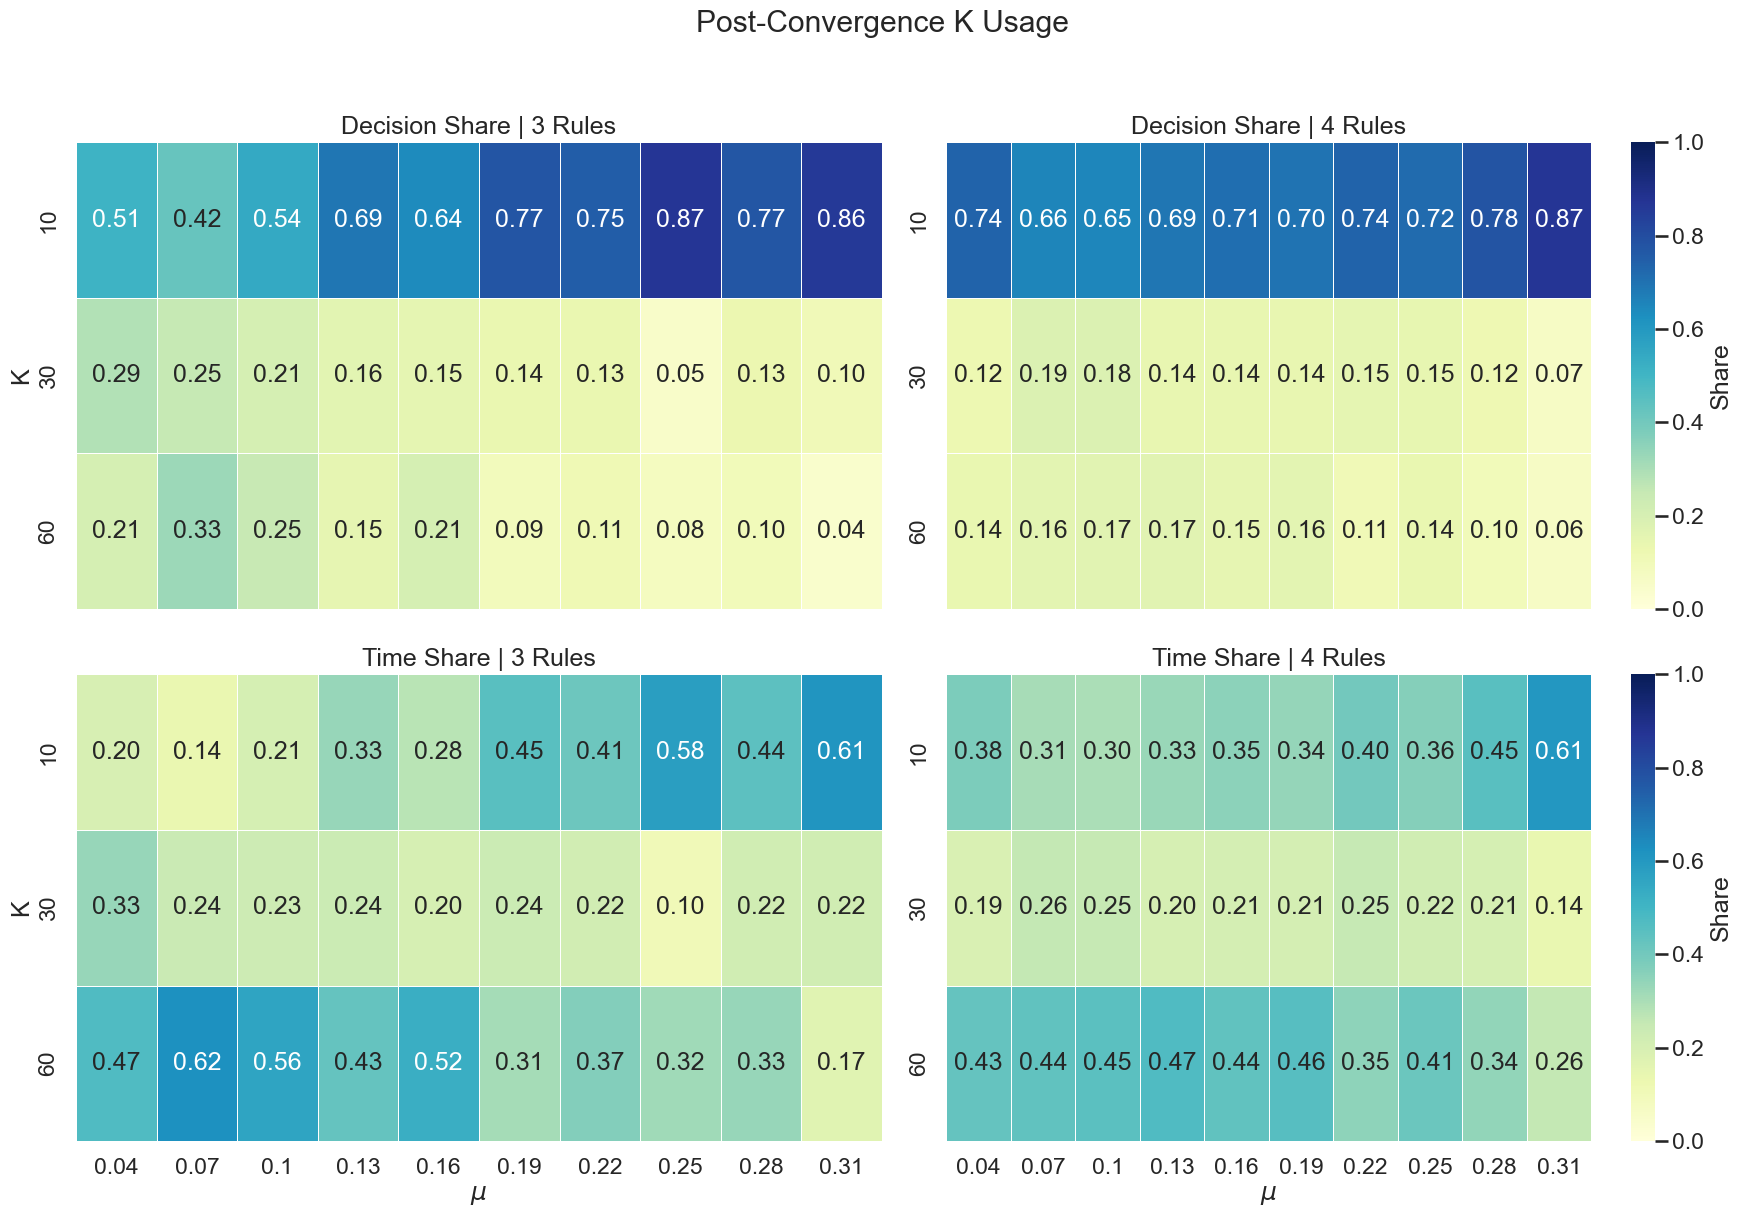

In [27]:
plot_share_heatmaps(
    k_share_summary,
    row_key="K",
    row_orders=k_orders,
    title="Post-Convergence K Usage",
)

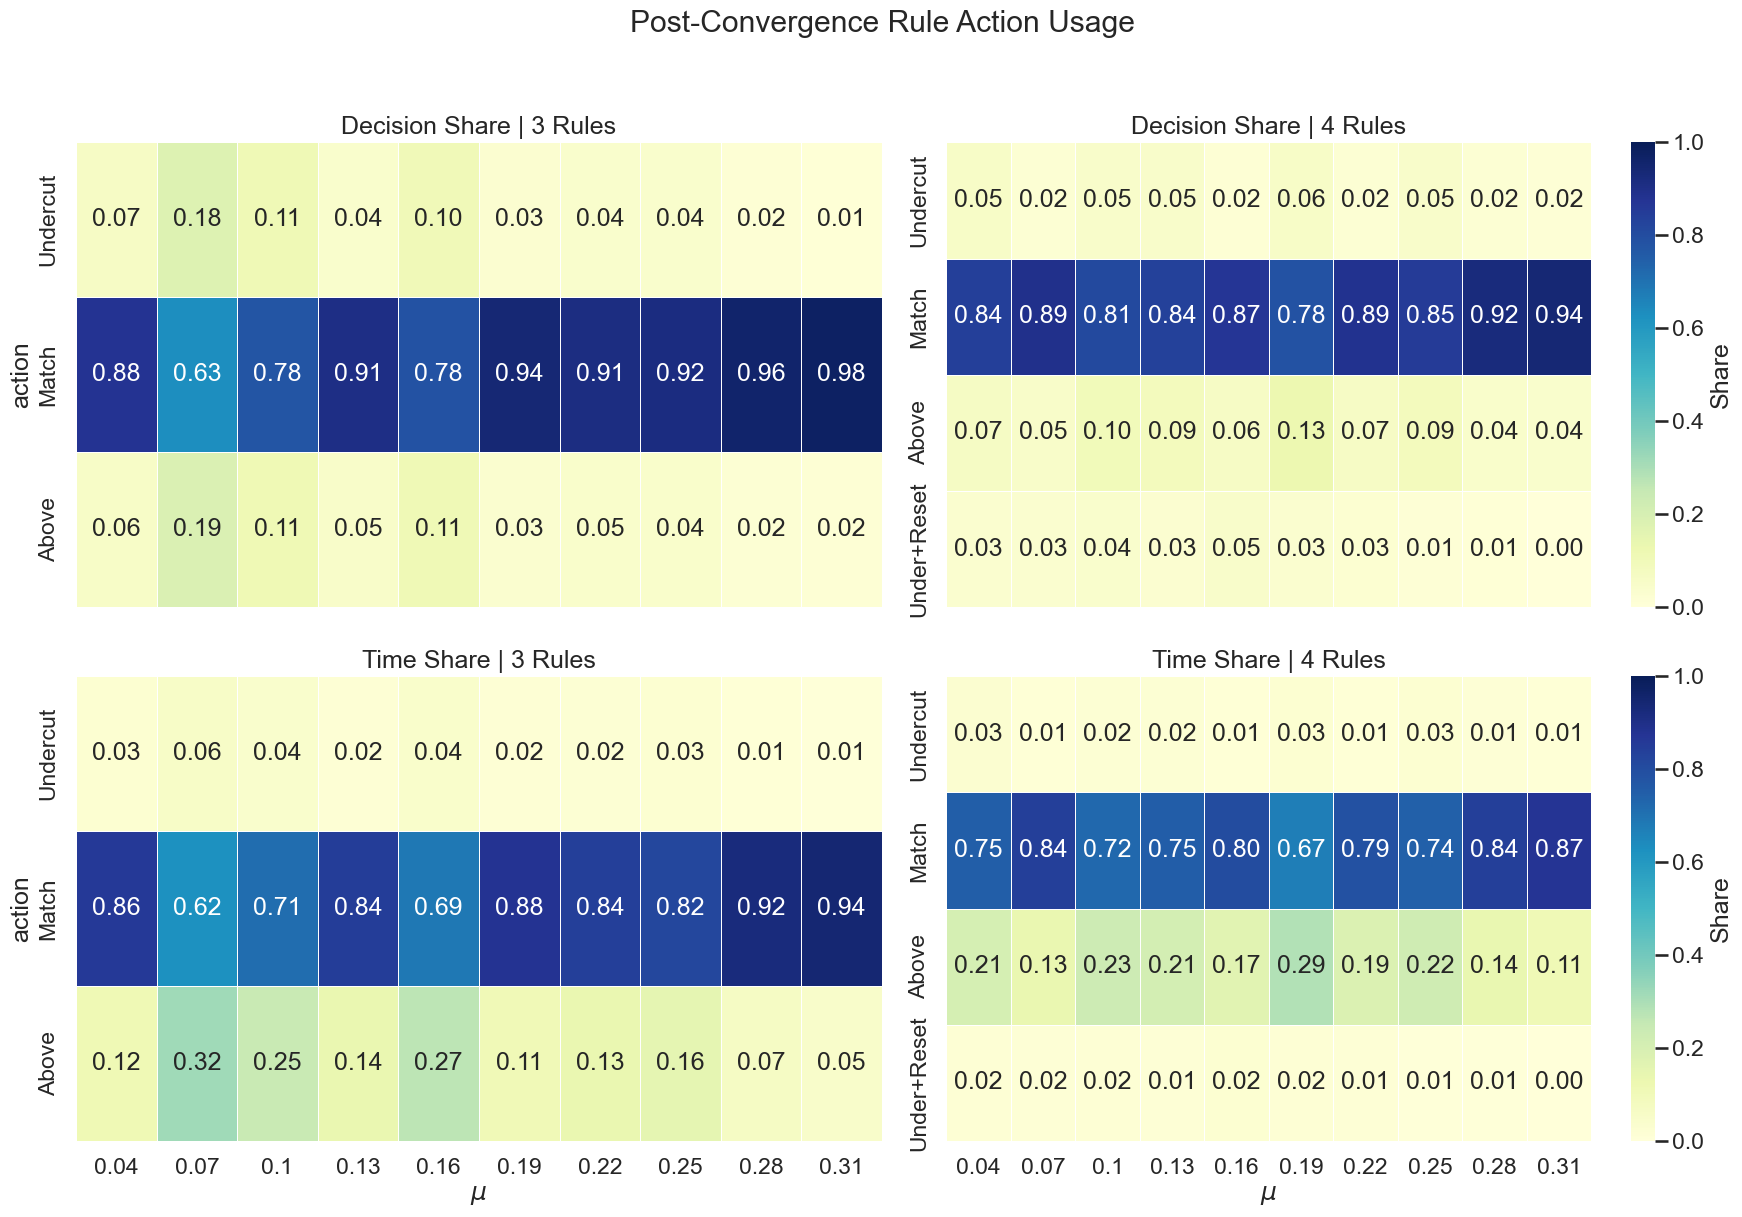

In [11]:
plot_share_heatmaps(
    action_share_summary,
    row_key="action",
    row_orders=action_orders,
    title="Post-Convergence Rule Action Usage",
)

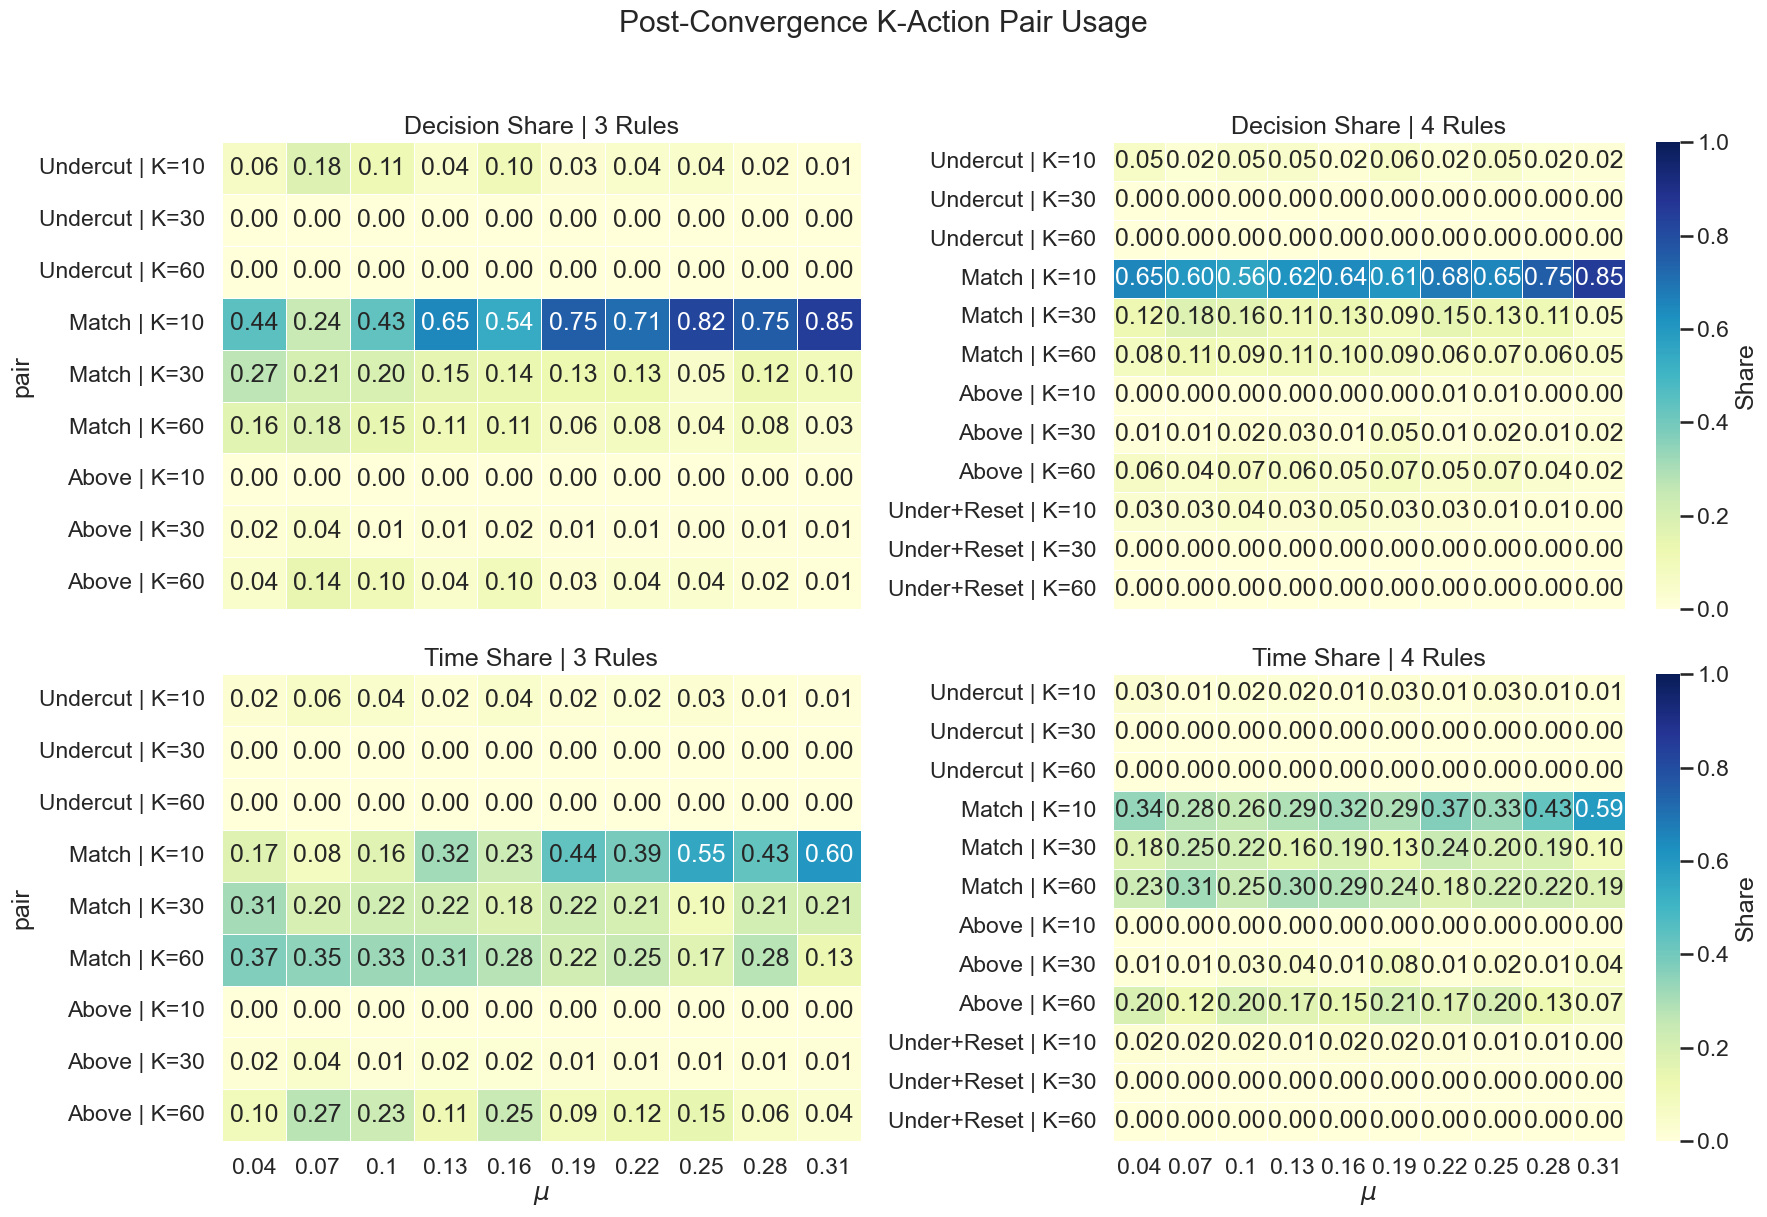

In [28]:
plot_share_heatmaps(
    pair_share_summary,
    row_key="pair",
    row_orders=pair_orders,
    title="Post-Convergence K-Action Pair Usage",
)